In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

models = [
    "Original DQN",
    "Reward-Shaped DQN",
    "Synthetic-Augmented DQN",
    "Cost-Sensitive DQN"
]

precision = [0.058824, 0.0, 0.0, 0.0]
recall = [0.333333, 0.0, 0.0, 0.0]
f1 = [0.1, 0.0, 0.0, 0.0]

rewards = [82.0, 1176.0, 1174.5, -32.3]

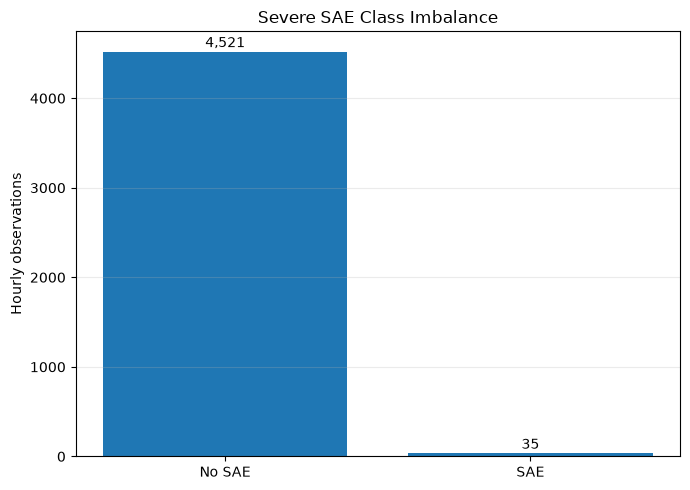

In [2]:
labels = ["No SAE", "SAE"]
counts = [4521, 35]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, counts)

plt.ylabel("Hourly observations")
plt.title("Severe SAE Class Imbalance")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 50,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

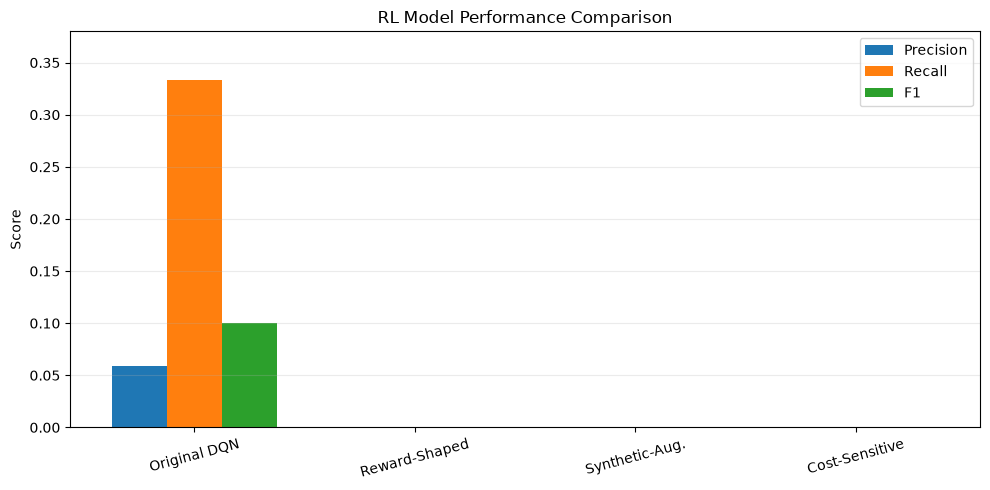

In [3]:
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1")

plt.xticks(
    x,
    ["Original DQN", "Reward-Shaped",
     "Synthetic-Aug.", "Cost-Sensitive"],
    rotation=15
)

plt.ylabel("Score")
plt.title("RL Model Performance Comparison")
plt.ylim(0, 0.38)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

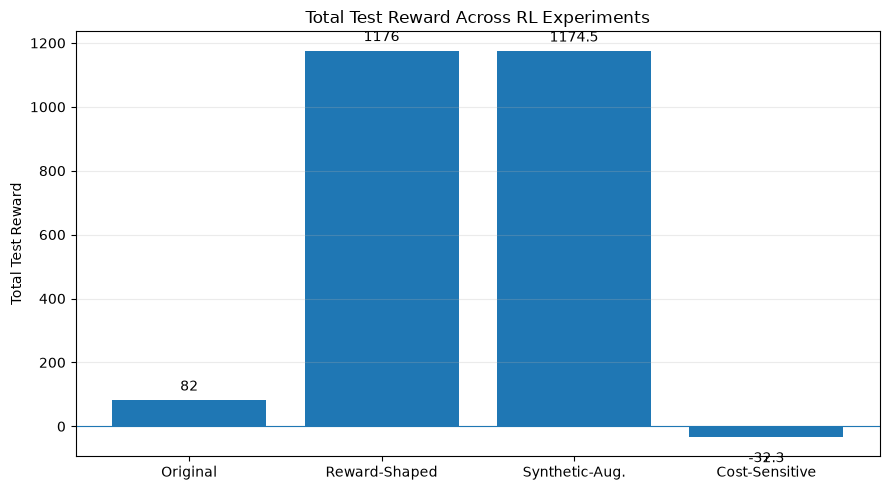

In [4]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    ["Original", "Reward-Shaped",
     "Synthetic-Aug.", "Cost-Sensitive"],
    rewards
)

plt.axhline(0, linewidth=0.8)

plt.ylabel("Total Test Reward")
plt.title("Total Test Reward Across RL Experiments")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, rewards):
    y = value + 30 if value >= 0 else value - 80
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{value:g}",
        ha="center"
    )

plt.tight_layout()
plt.show()

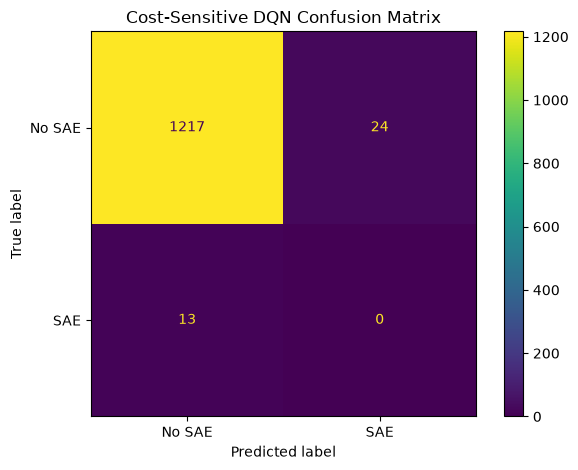

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([
    [1217, 24],
    [13, 0]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No SAE", "SAE"]
)

disp.plot()

plt.title("Cost-Sensitive DQN Confusion Matrix")
plt.tight_layout()
plt.show()